In [1]:
#| output:false

from Scripts import reyburn
ndeaths = reyburn.data.query('died == 1').count().iloc[0]
severe, deaths = reyburn.median_ages()

Severe malaria and mortality data from @reyburn_association_2005 was downloaded from the [journal website](https://royalsocietypublishing.org/doi/suppl/10.1098/rspb.2014.2657). The spreadsheet contains `{python} len(reyburn.data)` severe malaria episodes from hospital admissions from northeastern Tanzania collected over either six months (one hospital) or one year (nine hospitals) in 2002. Transmission intensity was stratified by village height above sea-level: high intensity below 600m, medium intensity from 600-1200m and low intensity above 1200m. There were `{python} ndeaths` deaths in total, giving an average severe case fatality risk (CFR) of `{python} f'{ndeaths/len(reyburn.data):.1%}'`. 

The age distributions of severe malaria episodes and deaths, across the three transmission intensities, are shown in the @fig-fig1. The number of severe malaria episodes and deaths reflects transmission intensity. As expected most cases occur in children less than 5 years of age, and the median ages of severe malaria and deaths reduce as transmission intensity increases (@tbl-table1).

Transmission | Median age of severe malaria (years) | Median age of death (years)
:-- | -----: | -----: 
high | `{python} f"{severe['high']:.1f}"` | `{python} f"{deaths['high']:.1f}"`
medium | `{python} f"{severe['medium']:.1f}"` | `{python} f"{deaths['medium']:.1f}"`
low | `{python} f"{severe['low']:.1f}"` | `{python} f"{deaths['low']:.1f}"`

: Median ages of severe malaria and deaths across transmission intensities {#tbl-table1 .striped}

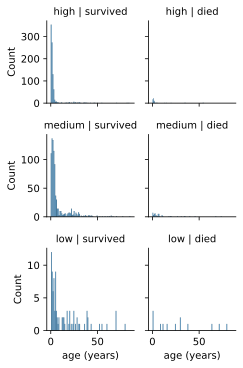

In [2]:
#| label: fig-fig1
#| fig-cap: "Raw counts of severe malaria episodes in people that either survived or died by age and transmission intensity [@reyburn_association_2005]."

g = reyburn.plot_raw_data()

# Age-specific severe case fatality risk

To visualise severe case fatality risk (@fig-fig2), the data are pooled across transmission intensities and binned with age boundaries of 0, 1, 2, 3, 4, 5, 10, 15, 20 and 80 years. CFR is defined as the number of deaths in a bin divided by the number of severe malaria cases in a bin.

CFR shows a decline from ages 0 to about 3-4 years of age, then shows a rise at about 5 years of age and then a plateau thereafter. Above 20 years old, the scarcity of deaths makes the estimation unreliable. The dip in CFR is corroborated by data from @marsh_malaria_1999, although the minimum occurs in 1 year olds in that study.

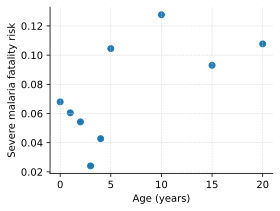

In [3]:
#| label: fig-fig2
#| fig-cap: "Age-specific risk of death among severe malaria cases pooled across transmission intensities from @reyburn_association_2005."

fig, ax = reyburn.plot_risk_pooled_data()

# Fit of GAM model to the raw data

To estimate the age-specific CFR we fitted a logistic generalised additive model with binomial errors to the raw data (up to 20 years old) using pyGAM [@serven_pygam_2018]. We fit a spline term to age and a feature term to transmission intensity. The code is in [Scripts/reyburn.py](Scripts/reyburn.py). 

The partial dependence functions with 95% CIs (red dashed lines) of the two model terms (@fig-fig3) reveal a significant effect of age but not of transmission intensity. Which suggests CFR is age-specific but with no evidence of differences in CFR across transmission intensities.

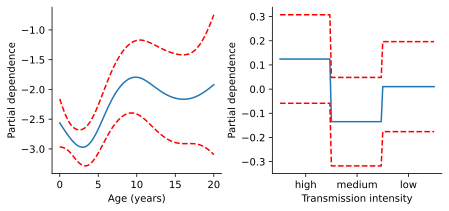

In [4]:
#| label: fig-fig3
#| fig-cap: "Partial dependence plots from the fitted GAM showing the effect of age and transmission intensity on CFR."

gam = reyburn.fit_GAM()
fig, axs = reyburn.plot_partial_dependence(gam)

## Estimated age-specific CFR

Above 10 years of age the estimate becomes highly uncertain due to sparsity of deaths. The drop in the curve in @fig-fig3 after its peak at 10 years of age is an artifact of fitting GAM splines. Moreover, it is inconsistent with observations that adults are more at risk of death from severe malaria than children [@greenberg_mortality_1990; @baird_age-dependent_1998; @dondorp_relationship_2008]. Although we do not include increasing risk of mortality in adults in our model as almost all deaths occur before 20 years of age. We therefore assume that CFR plateaus from age 10 onwards. 

The GAM estimated mean age-specific CFR (dashed line) with 95% CIs and the age-stratified data (circles) are shown in the @fig-fig4. Our model uses the mean age-specific CFR. 

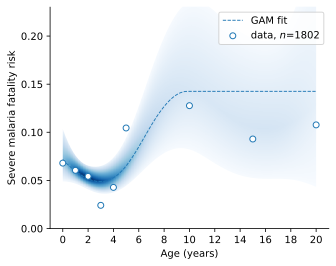

In [5]:
#| label: fig-fig4
#| fig-cap: "Estimated mean age-specific CFR (dashed line) with 95% CI (blue band) and age-stratified data (circles) from @reyburn_association_2005."

gam = reyburn.fit_GAM()
XX, fit, cfr, cis = reyburn.cfr_mean_CI(gam)
fig, ax = reyburn.plot_GAM_mean_CI_data(XX, fit, cfr, cis)

In [6]:
#| output: false

# cfr by year of age to hardcode into model.py
gam = reyburn.fit_GAM()
XX, fit, cfr, cis = reyburn.cfr_mean_CI(gam)

XX = range(12)
print(list(cfr(XX).round(3)))


[0.072, 0.06, 0.052, 0.049, 0.053, 0.065, 0.085, 0.108, 0.127, 0.139, 0.143, 0.143]


::: {#refs}
:::